In [1]:
import os
import urllib.request
import cv2
import dlib
import numpy as np
import matplotlib.pyplot as plt

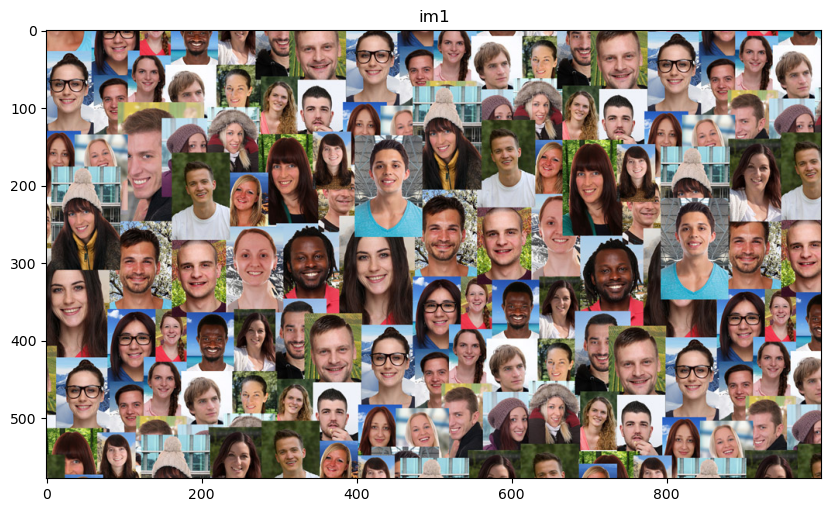

In [4]:
img = cv2.imread('Downloads/im1.jpg')
h, w = img.shape[:2]
max_side = 1400
scale = min(1.0, max_side / max(h, w))
if scale < 1.0:
    img = cv2.resize(img, (int(w*scale), int(h*scale)), interpolation=cv2.INTER_AREA)

plt.figure(figsize=(10,7))
plt.imshow(cv2.cvtColor(img, cv2.COLOR_BGR2RGB))
plt.title("im1")
plt.show()

In [15]:
YUNET_PATH = "models/face_detection_yunet_2023mar.onnx"
YUNET_URL  = "https://raw.githubusercontent.com/opencv/opencv_zoo/main/models/face_detection_yunet/face_detection_yunet_2023mar.onnx"

os.makedirs("models", exist_ok=True)
if not os.path.exists(YUNET_PATH):
    urllib.request.urlretrieve(YUNET_URL, YUNET_PATH)
h, w = img.shape[:2]
score_thr = 0.7   
nms_thr   = 0.3
top_k     = 5000

yunet = cv2.FaceDetectorYN.create(YUNET_PATH, "", (w, h), score_thr, nms_thr, top_k)

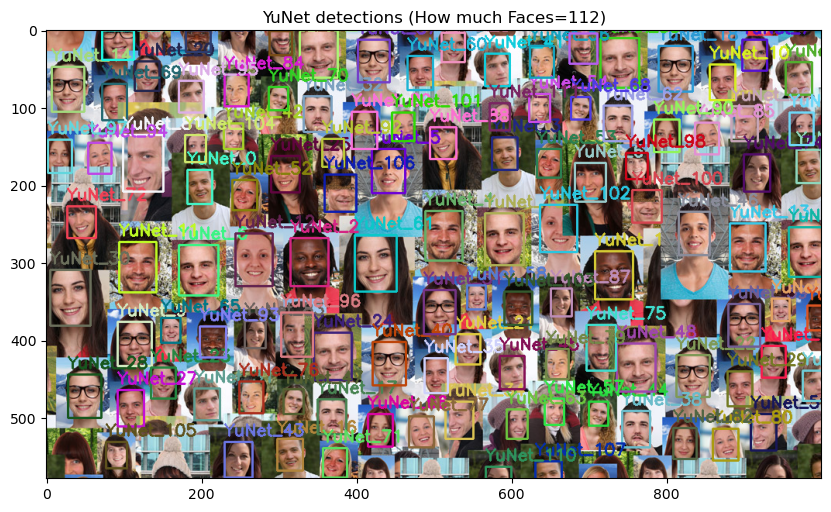

In [20]:
_, faces = yunet.detect(img)

yunet_vis = img.copy()
yunet_count = 0
rng = np.random.default_rng(10)

if faces is not None:
    yunet_count = len(faces)

    for i, f in enumerate(faces):
        x, y, bw, bh = f[0:4]
        x1, y1, x2, y2 = int(x), int(y), int(x + bw), int(y + bh)

        color = tuple(int(c) for c in rng.integers(0, 255, size=3))

        cv2.rectangle(yunet_vis, (x1, y1), (x2, y2), color, 2)
        cv2.putText(yunet_vis, f"YuNet_{i}", (x1, max(0, y1-8)),
                    cv2.FONT_HERSHEY_SIMPLEX, 0.7, color, 2)

plt.figure(figsize=(10,7))
plt.imshow(cv2.cvtColor(yunet_vis, cv2.COLOR_BGR2RGB))
plt.title(f"YuNet detections (How much Faces={yunet_count})")
plt.show()

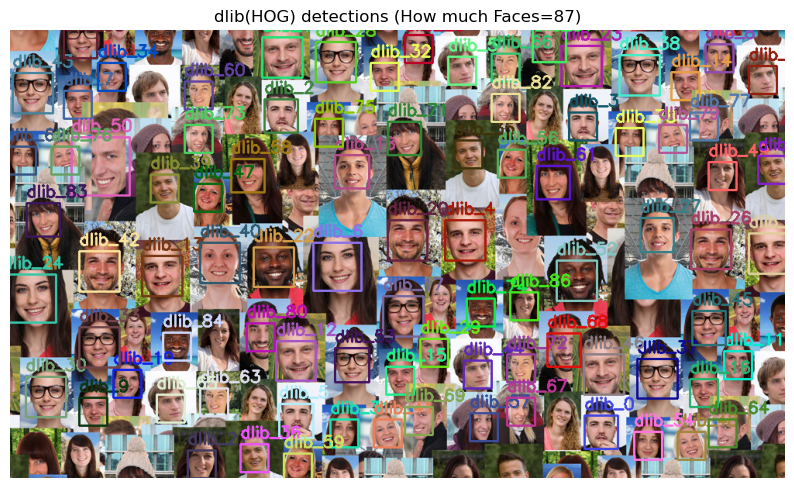

In [21]:
dlib_detector = dlib.get_frontal_face_detector()
upsample = 1  

gray = cv2.cvtColor(img, cv2.COLOR_BGR2GRAY)
rects = dlib_detector(gray, upsample)

dlib_vis = img.copy()
dlib_count = len(rects)
rng = np.random.default_rng(20)

for i, r in enumerate(rects):
    x1, y1, x2, y2 = r.left(), r.top(), r.right(), r.bottom()
    color = tuple(int(c) for c in rng.integers(0, 255, size=3))

    cv2.rectangle(dlib_vis, (x1, y1), (x2, y2), color, 2)
    cv2.putText(dlib_vis, f"dlib_{i}", (x1, max(0, y1-8)),
                cv2.FONT_HERSHEY_SIMPLEX, 0.7, color, 2)
plt.figure(figsize=(10,7))
plt.imshow(cv2.cvtColor(dlib_vis, cv2.COLOR_BGR2RGB))
plt.title(f"dlib(HOG) detections (How much Faces={dlib_count})")
plt.axis("off")
plt.show()

YuNet faces: 112
dlib faces: 87


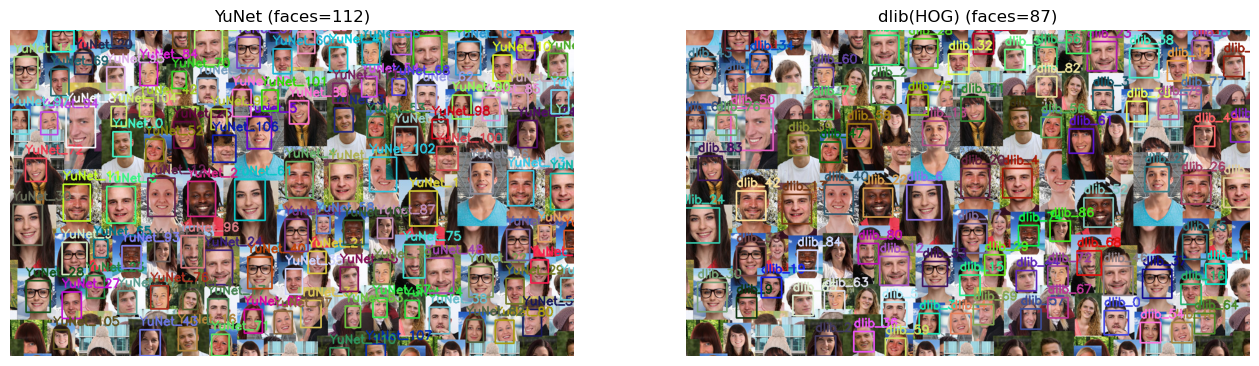

In [22]:
print("YuNet faces:", yunet_count)
print("dlib faces:", dlib_count)

fig, ax = plt.subplots(1, 2, figsize=(16, 7))

ax[0].imshow(cv2.cvtColor(yunet_vis, cv2.COLOR_BGR2RGB))
ax[0].set_title(f"YuNet (faces={yunet_count})")
ax[0].axis("off")

ax[1].imshow(cv2.cvtColor(dlib_vis, cv2.COLOR_BGR2RGB))
ax[1].set_title(f"dlib(HOG) (faces={dlib_count})")
ax[1].axis("off")

plt.show()

In [ ]:
#Well, yunet is worth using if you want to detect many faces, and dlib is good if simplicity and autonomy are important, and it works well when the faces are large and looking directly at the camera.